In [1]:
zip_path = "/content/drive/MyDrive/shoe.zip"
extract_path = "/content/edges2shoes"

In [2]:
import zipfile

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

print("Dataset extracted successfully")

Dataset extracted successfully


In [3]:
import os

print("Train images:", len(os.listdir("/content/train")))
print("Validation images:", len(os.listdir("/content/val")))

Train images: 49825
Validation images: 200


In [4]:
!pip install torch torchvision tqdm matplotlib

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.utils import save_image
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from PIL import Image
import os
from tqdm import tqdm
import os

In [6]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IMG_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 50

LR = 0.0002
BETA1 = 0.5
L1_LAMBDA = 100

In [7]:
BASE_DIR = "/content/drive/MyDrive/pix2pix_lab"

CHECKPOINT_DIR = f"{BASE_DIR}/checkpoints"
OUTPUT_DIR = f"{BASE_DIR}/outputs"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [8]:
class Pix2PixDataset(Dataset):

    def __init__(self, root_dir):

        self.root_dir = root_dir

        self.images = os.listdir(root_dir)

        self.transform = transforms.Compose([
            transforms.Resize((256,512)),
            transforms.ToTensor(),
            transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):

        img_path = os.path.join(self.root_dir, self.images[index])
        image = Image.open(img_path).convert("RGB")

        image = self.transform(image)

        input_image = image[:, :, :256]
        target_image = image[:, :, 256:]

        return input_image, target_image

In [9]:
train_dataset = Pix2PixDataset("/content/train")
val_dataset = Pix2PixDataset("/content/val")

train_loader = DataLoader(train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True)

val_loader = DataLoader(val_dataset,
                        batch_size=1,
                        shuffle=False)

In [10]:
train_dataset = Pix2PixDataset("/content/train")
val_dataset = Pix2PixDataset("/content/val")

train_loader = DataLoader(train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True)

val_loader = DataLoader(val_dataset,
                        batch_size=1,
                        shuffle=False)

In [11]:
class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        def down(in_c,out_c):
            return nn.Sequential(
                nn.Conv2d(in_c,out_c,4,2,1),
                nn.BatchNorm2d(out_c),
                nn.LeakyReLU(0.2)
            )

        def up(in_c,out_c):
            return nn.Sequential(
                nn.ConvTranspose2d(in_c,out_c,4,2,1),
                nn.BatchNorm2d(out_c),
                nn.ReLU()
            )

        self.d1 = down(3,64)
        self.d2 = down(64,128)
        self.d3 = down(128,256)
        self.d4 = down(256,512)

        self.u1 = up(512,256)
        self.u2 = up(512,128)
        self.u3 = up(256,64)

        self.final = nn.ConvTranspose2d(128,3,4,2,1)

    def forward(self,x):

        d1 = self.d1(x)
        d2 = self.d2(d1)
        d3 = self.d3(d2)
        d4 = self.d4(d3)

        u1 = self.u1(d4)
        u1 = torch.cat([u1,d3],1)

        u2 = self.u2(u1)
        u2 = torch.cat([u2,d2],1)

        u3 = self.u3(u2)
        u3 = torch.cat([u3,d1],1)

        return torch.tanh(self.final(u3))

In [12]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        def block(in_c,out_c,stride):
            return nn.Sequential(
                nn.Conv2d(in_c,out_c,4,stride,1),
                nn.BatchNorm2d(out_c),
                nn.LeakyReLU(0.2)
            )

        self.model = nn.Sequential(
            block(6,64,2),
            block(64,128,2),
            block(128,256,2),
            nn.Conv2d(256,1,4,1,1)
        )

    def forward(self,x,y):
        x = torch.cat([x,y],1)
        return self.model(x)

In [13]:
gen = Generator().to(DEVICE)
disc = Discriminator().to(DEVICE)

In [14]:
BCE = nn.BCEWithLogitsLoss()
L1 = nn.L1Loss()

opt_gen = optim.Adam(gen.parameters(), lr=LR, betas=(BETA1,0.999))
opt_disc = optim.Adam(disc.parameters(), lr=LR, betas=(BETA1,0.999))

In [15]:
start_epoch = 0

gen_ckpt = f"{CHECKPOINT_DIR}/gen_latest.pth"
disc_ckpt = f"{CHECKPOINT_DIR}/disc_latest.pth"

if os.path.exists(gen_ckpt):

    print("Loading checkpoint...")

    gen_checkpoint = torch.load(gen_ckpt)
    disc_checkpoint = torch.load(disc_ckpt)

    gen.load_state_dict(gen_checkpoint["model"])
    disc.load_state_dict(disc_checkpoint["model"])

    opt_gen.load_state_dict(gen_checkpoint["optimizer"])
    opt_disc.load_state_dict(disc_checkpoint["optimizer"])

    start_epoch = gen_checkpoint["epoch"] + 1

    print("Resuming from epoch:", start_epoch)

Loading checkpoint...
Resuming from epoch: 20


In [ ]:
for epoch in range(start_epoch, EPOCHS):

    print(f"\nStarting Epoch {epoch}/{EPOCHS}")

    loop = tqdm(train_loader, desc=f"Epoch {epoch}")

    for idx,(x,y) in enumerate(loop):

        x = x.to(DEVICE)
        y = y.to(DEVICE)

        fake = gen(x)

        # Train Discriminator
        real_pred = disc(x,y)
        fake_pred = disc(x,fake.detach())

        loss_real = BCE(real_pred, torch.ones_like(real_pred))
        loss_fake = BCE(fake_pred, torch.zeros_like(fake_pred))

        D_loss = (loss_real + loss_fake)/2

        opt_disc.zero_grad()
        D_loss.backward()
        opt_disc.step()

        # Train Generator
        fake_pred = disc(x,fake)

        adv_loss = BCE(fake_pred, torch.ones_like(fake_pred))
        l1_loss = L1(fake,y) * L1_LAMBDA

        G_loss = adv_loss + l1_loss

        opt_gen.zero_grad()
        G_loss.backward()
        opt_gen.step()

        loop.set_postfix(
            epoch=epoch,
            G_loss=G_loss.item(),
            D_loss=D_loss.item()
        )

    print(f"Finished Epoch {epoch}")

    # Save checkpoint
    torch.save({
        "epoch": epoch,
        "model": gen.state_dict(),
        "optimizer": opt_gen.state_dict()
    }, f"{CHECKPOINT_DIR}/gen_latest.pth")

    torch.save({
        "epoch": epoch,
        "model": disc.state_dict(),
        "optimizer": opt_disc.state_dict()
    }, f"{CHECKPOINT_DIR}/disc_latest.pth")

In [ ]:
gen.eval()

epoch_folder = f"{OUTPUT_DIR}/epoch_{epoch}"
os.makedirs(epoch_folder, exist_ok=True)

for idx,(x,y) in enumerate(val_loader):

    x = x.to(DEVICE)

    with torch.no_grad():
        fake = gen(x)

    save_image(fake*0.5+0.5,
               f"{epoch_folder}/output_{idx}.png")

    if idx == 20:
        break

In [ ]:
import torch

best_path = "/content/drive/MyDrive/pix2pix_lab/checkpoints/best_generator.pth"

gen.load_state_dict(torch.load(best_path, map_location=DEVICE))
gen.to(DEVICE)
gen.eval()

print("Loaded best generator checkpoint")

In [ ]:
import os

OUTPUT_DIR = "/content/drive/MyDrive/pix2pix_lab/final_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
import matplotlib.pyplot as plt
from torchvision.utils import save_image

def denorm(x):
    return (x + 1) / 2

for idx, (x, y) in enumerate(val_loader):

    x = x.to(DEVICE)

    with torch.no_grad():
        fake = gen(x)

    inp = denorm(x[0]).permute(1,2,0).cpu()
    real = denorm(y[0]).permute(1,2,0)
    gen_img = denorm(fake[0]).permute(1,2,0).cpu()

    # show images
    fig, ax = plt.subplots(1,3, figsize=(12,4))

    ax[0].imshow(inp)
    ax[0].set_title("Input Edge")

    ax[1].imshow(real)
    ax[1].set_title("Ground Truth")

    ax[2].imshow(gen_img)
    ax[2].set_title("Generated")

    for a in ax:
        a.axis("off")

    plt.show()

    # save generated image
    save_image(gen_img.permute(2,0,1),
               f"{OUTPUT_DIR}/generated_{idx}.png")

    if idx == 10:
        break

  Baseline CNN Encoder–Decoder

In [16]:
import torch
import torch.nn as nn

class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3,64,4,2,1),
            nn.ReLU(),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128,256,4,2,1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128,64,4,2,1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64,3,4,2,1),
            nn.Tanh()
        )

    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [17]:
baseline = BaselineCNN().to(DEVICE)

criterion = nn.L1Loss()

optimizer = torch.optim.Adam(
    baseline.parameters(),
    lr=0.0002
)

In [20]:
from tqdm import tqdm

EPOCHS_BASELINE = 5

for epoch in range(EPOCHS_BASELINE):

    loop = tqdm(train_loader)

    for x,y in loop:

        x = x.to(DEVICE)
        y = y.to(DEVICE)

        pred = baseline(x)

        loss = criterion(pred,y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loop.set_postfix(loss=loss.item())

    print("Epoch",epoch,"Loss",loss.item())

100%|██████████| 6229/6229 [08:31<00:00, 12.19it/s, loss=0.188]


Epoch 0 Loss 0.18822726607322693


100%|██████████| 6229/6229 [08:34<00:00, 12.11it/s, loss=0.22]


Epoch 1 Loss 0.21970772743225098


100%|██████████| 6229/6229 [08:32<00:00, 12.17it/s, loss=0.299]


Epoch 2 Loss 0.29930415749549866


100%|██████████| 6229/6229 [08:33<00:00, 12.13it/s, loss=0.234]


Epoch 3 Loss 0.23388533294200897


100%|██████████| 6229/6229 [08:35<00:00, 12.09it/s, loss=0.261]

Epoch 4 Loss 0.2608838379383087


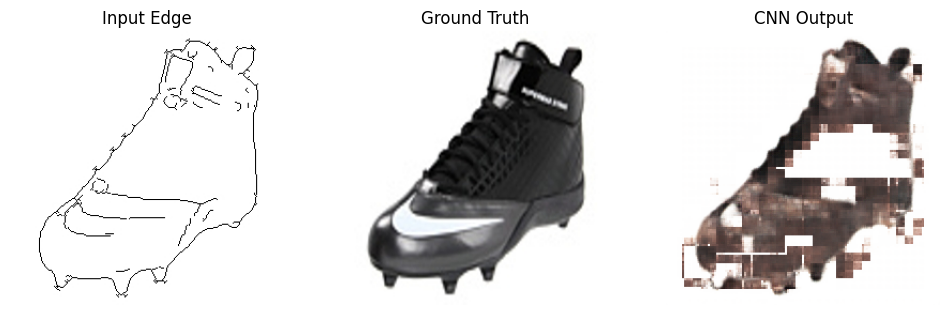

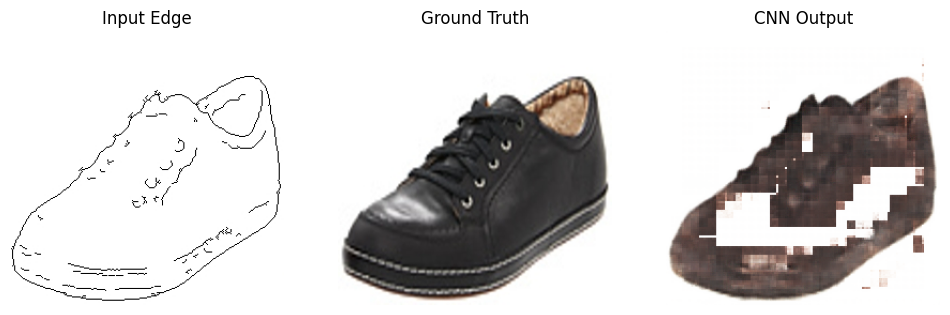

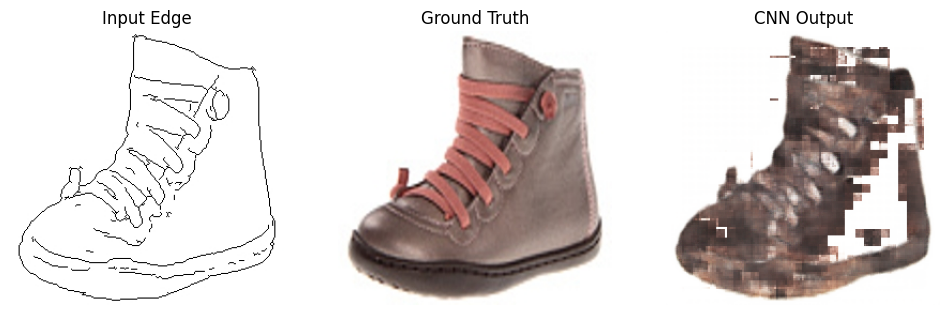

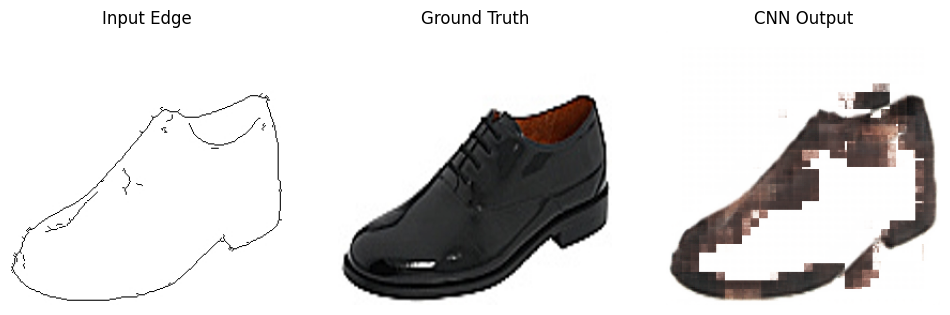

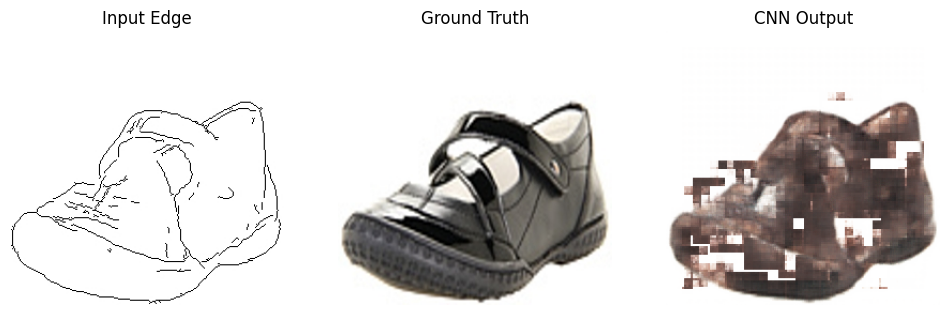

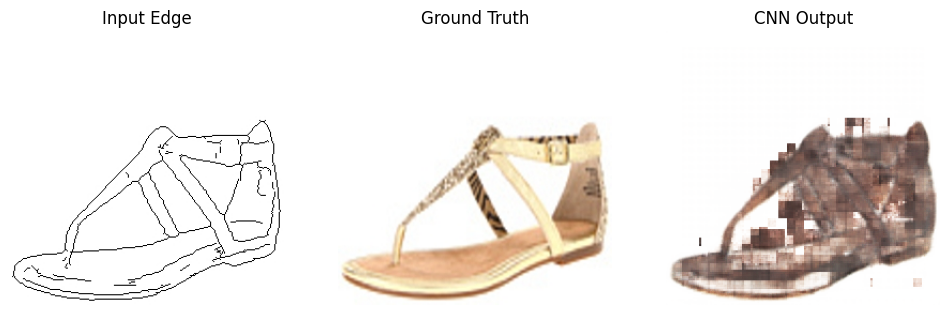

In [21]:
baseline.eval()

import matplotlib.pyplot as plt

def denorm(x):
    return (x+1)/2

for idx,(x,y) in enumerate(val_loader):

    x = x.to(DEVICE)

    with torch.no_grad():
        fake = baseline(x)

    inp = denorm(x[0]).permute(1,2,0).cpu()
    real = denorm(y[0]).permute(1,2,0)
    gen = denorm(fake[0]).permute(1,2,0).cpu()

    fig,ax = plt.subplots(1,3,figsize=(12,4))

    ax[0].imshow(inp)
    ax[0].set_title("Input Edge")

    ax[1].imshow(real)
    ax[1].set_title("Ground Truth")

    ax[2].imshow(gen)
    ax[2].set_title("CNN Output")

    for a in ax:
        a.axis("off")

    plt.show()

    if idx == 5:
        break